## Neccessary Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Trapezoidal Rule

In [3]:
def Trapezoid_Rule(n,f,a,b): 
    #create a uniform mesh
    h = (b-a) / n

    # compute summation from formula
    summation = 0
    for i in range(1,n): 
        summation += f(a + i*h)

    # put together integral formula
    integral = h / 2 * (f(a) + 2*summation + f(b))

    # track function evaluations "computational complexity"
    n_evals = n + 1
    return integral, n_evals

## Adaptive Trapezoidal Rule

In [5]:
def Adaptive_Trapezoid(f, a, b, tol, m_init=1):
    # start with one mesh
    m = m_init

    # compute "coarse" integral 
    I_coarse, _ = Trapezoid_Rule(m, f, a, b)
    total_evals = m + 1

    # Begin helfing the interval size 
    while True:
        m = 2 * m
        # evaluate on the fine grid
        I_fine, evals = Trapezoid_Rule(m, f, a, b)
        total_evals += evals #track evals

        # if difference is below tolerance check => return new val
        if abs(I_fine - I_coarse) < tol:
            return I_fine, m, total_evals

        # elsewise repeat
        I_coarse = I_fine

## Coefficients of Legendre polynomials

In [6]:
def Legendre_Coeff(n): 
    # Coefficients of Legendre polynomials
    # [A,B] are the alpha(k) and beta(k) coefficients 
    # for the Legendre Polynomial of degree N
    if n < 1:
        raise ValueError('n must be >= 1') 

    # initialize storage for coefficients
    a = np.zeros(n)
    b = np.zeros(n)

    # set inital beta coeff
    b[0] = 2

    # compute the recurrance 
    for k in range(1,n):
        b[k] = k**2 / (4*k**2 - 1)

    return a, b

## Coefficients of Gauss-Legendre Form

In [7]:
def GL_Coeff(n): 
    # Gauss-Legendre formula
    # [X,W] are the nodes and the weights of the
    # Gauss-Legendre formula with N nodes

    if n < 1:
        raise ValueError('n must be >= 1') 

    # call function from above
    a, b = Legendre_Coeff(n)

    # Compute the Jacobi Matrix
    JacM = np.diag(a) + np.diag(np.sqrt(b[1:n]),1) + np.diag(np.sqrt(b[1:n]),-1)
    
    # compute jacobi eigenpair
    eigenvalues, eigenvectors = np.linalg.eigh(JacM)
    x = eigenvalues

    # set weights
    w = b[0] * eigenvectors[0, :]**2

    #find largest eigenval
    ind = np.argsort(x)
    # compute weights and nodes 
    x = x[ind]
    w = w[ind]
    
    return x, w

## Guass-Legandre Quadrature 

In [9]:
def GL_Quadrature(n, f, a, b, m): 
    # compute nodes and weights
    t, w = GL_Coeff(n)

    # if single global interval
    # map from [-1,1] to [a,b]
    if m == 0: 
        mid = (a+b) / 2
        half = (b-a) / 2
        x_nodes = half * t + mid
        integral = half * np.dot(w, f(x_nodes))
        n_evals = n

    # if interval is split
    else:
        # split into uniform subintervals
        h = (b-a) / m
        half_h = h / 2
        total = 0

        for k in range(m):
            a_k = a + k * h # left endpoint
            mid_k = a_k + half_h 
            x_nodes = half_h * t + mid_k # map from [-1,1] to [a,b]
            total += np.dot(w, f(x_nodes)) # compute weighted sum

        # account for change of variables
        integral = half_h * total
        n_evals = n * m

    return integral, n_evals

## Test Functions & Exact Values

In [11]:
# Test Functions
f1 = lambda x: np.exp(x) 
f2 = lambda x: np.exp(np.sin(2*x)) * np.cos(2*x) 
f3 = lambda x: np.tanh(x) 
f4 = lambda x: x * np.cos(2*np.pi*x) 
f5 = lambda x: x + (1 / x) 
functions = [f1, f2, f3, f4, f5]

# Test functions exact integral value
f1_exact = np.exp(3) - 1 
f2_exact = 0.5 * (-1 + np.exp(np.sqrt(3) / 2))
f3_exact = np.log(np.cosh(1) / np.cosh(2))
f4_exact = -1 / (2 * np.pi**2)
f5_exact = (2.5**2 - 0.1**2) / 2 + np.log(2.5 / 0.1)
exact = [f1_exact, f2_exact, f3_exact, f4_exact, f5_exact]

## Task 1 - Subinterval Size Estimates

In [12]:
# Compute Max Second Derivative for bound
def second_derivative_max(f, a, b, N = 1000): 
    x = np.linspace(a,b,N)
    h = x[1] - x[0]
    f2 = np.abs(np.diff(f(x),2)) / h**2 
    return np.max(f2)

# Compute subinterval estimate size 
def subinterval_bound(f, a, b, tol): 
    second_derivative = second_derivative_max(f, a, b,)
    H_m = np.sqrt(12 * tol / ((b - a) * second_derivative))
    n = int(np.ceil((b-a)/ H_m))
    return H_m, n, second_derivative

# set list of tolerances, function names, and interval sizes 
tols = [1e-2, 1e-4, 1e-6, 1e-8]
names = ['f1', 'f2', 'f3', 'f4', 'f5']
intervals = [(0,3), (0,np.pi/3), (-2,1), (0,3.5), (0.1, 2.5)]

# loop through function name, test function, interval 
for fname, f, (a,b) in zip(names, functions, intervals):
    print(f"\n{fname} on [{a}, {b:.4f}]\n")
    print(f"  {'tol':>8}  {'max|f´´|':>12}  {'Hm':>12}  {'n':>6}")
    print(f"  {'-'*8}  {'-'*12}  {'-'*12}  {'-'*6}")
    
    # loop through tolerances
    for tol in tols:
        # compute subinterval size and how many and max second derivative
        Hm, n, M2 = subinterval_bound(f, a, b, tol)
        print(f"  {tol:>8.0e}  {M2:>12.4f}  {Hm:>12.6f}  {n:>6}")


f1 on [0, 3.0000]

       tol      max|f´´|            Hm       n
  --------  ------------  ------------  ------
     1e-02       20.0253      0.044693      68
     1e-04       20.0253      0.004469     672
     1e-06       20.0253      0.000447    6713
     1e-08       20.0253      0.000045   67125

f2 on [0, 1.0472]

       tol      max|f´´|            Hm       n
  --------  ------------  ------------  ------
     1e-02       16.2830      0.083890      13
     1e-04       16.2830      0.008389     125
     1e-06       16.2830      0.000839    1249
     1e-08       16.2830      0.000084   12484

f3 on [-2, 1.0000]

       tol      max|f´´|            Hm       n
  --------  ------------  ------------  ------
     1e-02        0.7698      0.227951      14
     1e-04        0.7698      0.022795     132
     1e-06        0.7698      0.002280    1317
     1e-08        0.7698      0.000228   13161

f4 on [0, 3.5000]

       tol      max|f´´|            Hm       n
  --------  ------------  

## Task 2 - Trapezoid Rule Testing

In [14]:
def task2(f, a, b, exact, fname):
    # display error metrics 
    print(f"\n{fname} on [{a}, {b:.4f}] | Integral = {exact:.8f}\n")
    print(f"  {'tol':>8}  {'n':>6}  {'true error':>12}  {'apriori bound':>14}  {'observed err':>13}")
    print(f"-"*65)

    for tol in tols:
        #  get predicted n from PREVIOUS task
        Hm, n, M2 = subinterval_bound(f, a, b, tol)

        # trapezoidal with n
        I_fine, _ = Trapezoid_Rule(n, f, a, b)

        #run with 2n to get observed error estimate
        I_coarse, _ = Trapezoid_Rule(2*n, f, a, b)

        # compute errors
        true_err = abs(I_fine - exact)
        observed_err = abs(I_fine - I_coarse)

        # print results
        print(f"  {tol:>8.0e}  {n:>6}  {true_err:>12.4e}  {tol:>14.4e}  {observed_err:>13.4e}")

exact_vals = [f1_exact, f2_exact, f3_exact, f4_exact, f5_exact]
 #loop through all lists for task2
for fname, f, (a,b), exact in zip(names, functions, intervals, exact_vals):
    task2(f, a, b, exact, fname)


f1 on [0, 3.0000] | Integral = 19.08553692

       tol       n    true error   apriori bound   observed err
-----------------------------------------------------------------
     1e-02      68    3.0955e-03      1.0000e-02     2.3216e-03
     1e-04     672    3.1698e-05      1.0000e-04     2.3773e-05
     1e-06    6713    3.1764e-07      1.0000e-06     2.3823e-07
     1e-08   67125    3.1767e-09      1.0000e-08     2.3823e-09

f2 on [0, 1.0472] | Integral = 0.68872134

       tol       n    true error   apriori bound   observed err
-----------------------------------------------------------------
     1e-02      13    2.6678e-03      1.0000e-02     2.0013e-03
     1e-04     125    2.8829e-05      1.0000e-04     2.1622e-05
     1e-06    1249    2.8875e-07      1.0000e-06     2.1656e-07
     1e-08   12484    2.8903e-09      1.0000e-08     2.1677e-09

f3 on [-2, 1.0000] | Integral = -0.89122192

       tol       n    true error   apriori bound   observed err
-----------------------------

## Task 3 - Adaptive Trapezoid Rule Testing

In [15]:
def task3(f, a, b, exact, fname):
    # display task 3 results
    print(f"\n{fname} on [{a}, {b:.4f}] | Integral = {exact:.8f}\n")
    print(f"  {'tol':>8}  {'m_final':>8}  {'true error':>12}  {'apriori bound':>14}  {'observed err':>13}  {'evals':>6}")
    print(f"-"*75)

    # for each tol level
    for tol in tols:
        # compute adaptive trasp methods 
        I_fine, m_final, n_evals = Adaptive_Trapezoid(f, a, b, tol)
        I_coarse, m_c, _ = Adaptive_Trapezoid(f, a, b, tol*10)  # coarser run for observed error

        # compute error
        true_err = abs(I_fine - exact)
        observed_err = abs(I_fine - I_coarse)

        print(f"  {tol:>8.0e}  {m_final:>8}  {true_err:>12.4e}  {tol:>14.4e}  {observed_err:>13.4e}  {n_evals:>6}")
# loop through each list for testing
for fname, f, (a,b), exact in zip(names, functions, intervals, exact_vals):
    task3(f, a, b, exact, fname)


f1 on [0, 3.0000] | Integral = 19.08553692

       tol   m_final    true error   apriori bound   observed err   evals
---------------------------------------------------------------------------
     1e-02       128    8.7366e-04      1.0000e-02     1.3103e-02     263
     1e-04      1024    1.3651e-05      1.0000e-04     2.0477e-04    2058
     1e-06      8192    2.1330e-07      1.0000e-06     6.3989e-07   16397
     1e-08     65536    3.3329e-09      1.0000e-08     9.9981e-09  131088

f2 on [0, 1.0472] | Integral = 0.68872134

       tol   m_final    true error   apriori bound   observed err   evals
---------------------------------------------------------------------------
     1e-02        16    1.7606e-03      1.0000e-02     2.6652e-02      36
     1e-04       128    2.7494e-05      1.0000e-04     8.2484e-05     263
     1e-06      2048    1.0740e-07      1.0000e-06     1.6109e-06    4107
     1e-08     16384    1.6781e-09      1.0000e-08     2.5171e-08   32782

f3 on [-2, 1.0000]

## Task 4 - Gauss-Legandre Testing 

In [16]:
def task4(f, a, b, exact, fname):
    # display results
    print(f"\n{fname} on [{a}, {b:.4f}] | Integral = {exact:.8f}\n")
    print(f"  {'tol':>8}  {'GL m':>6}  {'GL evals':>9}  {'GL true err':>12}  {'Trap evals':>15}  {'Adapt evals':>17}")
    print(f"-"*80)

    # for each tol level
    for tol in tols:
        # Compute previous methods 
        Hm, n_trap, M2 = subinterval_bound(f, a, b, tol)
        _, trap_evals = Trapezoid_Rule(n_trap, f, a, b)
        _, m_adapt, adapt_evals = Adaptive_Trapezoid(f, a, b, tol)

        # compute GL method
        for m_gl in range(1, 10000):
            approx, gl_evals = GL_Quadrature(2, f, a, b, m=m_gl)
            if abs(approx - exact) < tol:
                break

        # compye error
        gl_true_err = abs(approx - exact)
        print(f"  {tol:>8.0e}  {m_gl:>6}  {gl_evals:>9}  {gl_true_err:>12.4e}  {trap_evals:>15}  {adapt_evals:>17}")

#loop through lists
for fname, f, (a,b), exact in zip(names, functions, intervals, exact_vals):
    task4(f, a, b, exact, fname)


f1 on [0, 3.0000] | Integral = 19.08553692

       tol    GL m   GL evals   GL true err       Trap evals        Adapt evals
--------------------------------------------------------------------------------
     1e-02       3          6    4.2813e-03               69                263
     1e-04       8         16    8.6978e-05              673               2058
     1e-06      25         50    9.1569e-07             6714              16397
     1e-08      78        156    9.6673e-09            67126             131088

f2 on [0, 1.0472] | Integral = 0.68872134

       tol    GL m   GL evals   GL true err       Trap evals        Adapt evals
--------------------------------------------------------------------------------
     1e-02       2          4    4.4001e-04               14                 36
     1e-04       4          8    4.2786e-05              126                263
     1e-06      11         22    7.7175e-07             1250               4107
     1e-08      33         66

## Convergence Visualization 

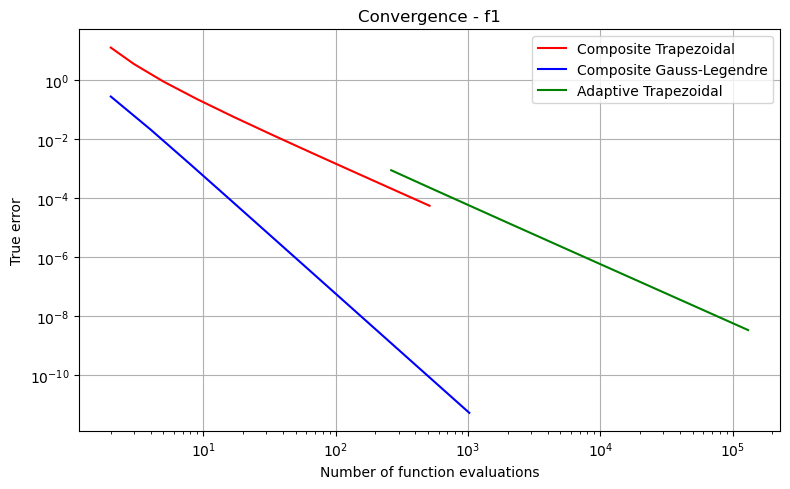

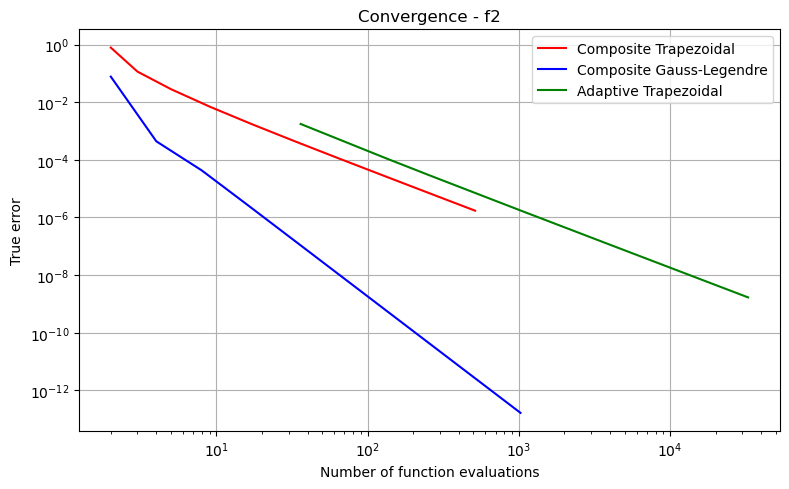

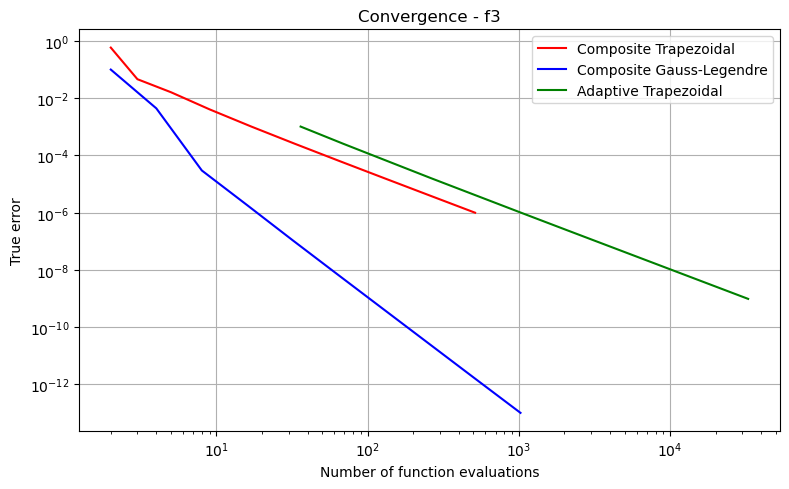

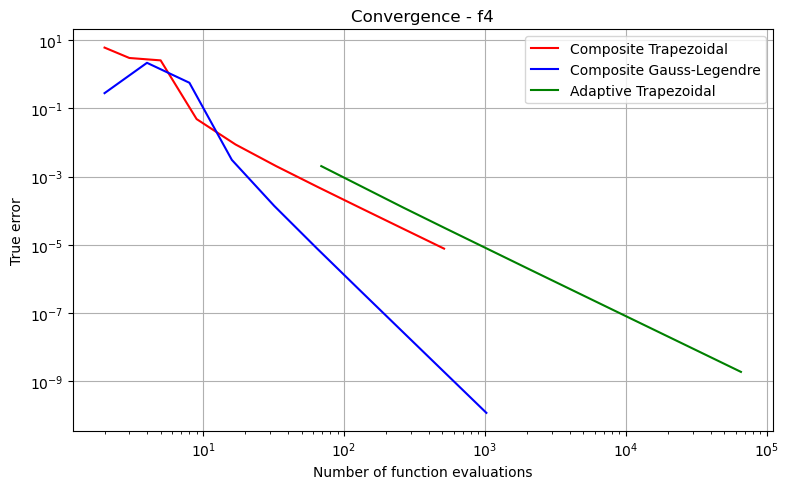

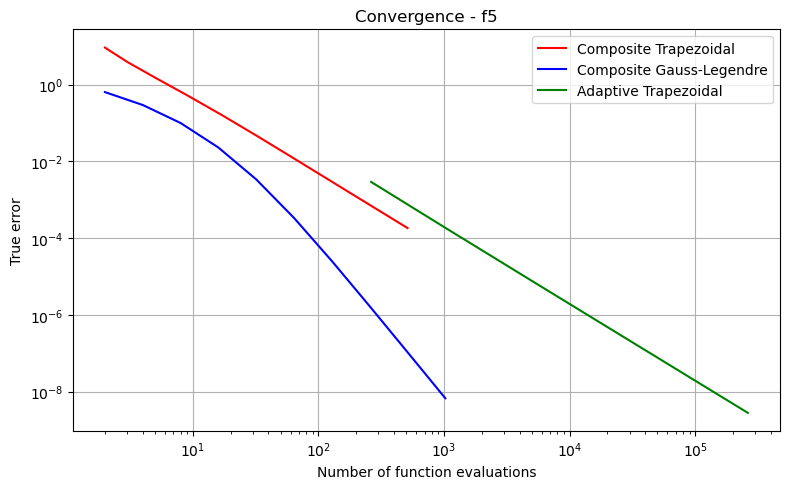

In [17]:
def convergence_plot(f, a, b, exact, fname):
    m_values = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

    # initialize storage
    trap_evals, trap_errors = [], []
    gl_evals, gl_errors = [], []

    for m in m_values:
        # Compute trapezoidal
        approx, evals = Trapezoid_Rule(m, f, a, b)
        trap_evals.append(evals)
        trap_errors.append(abs(approx - exact))

        # Compute gauss-legendre
        approx, evals = GL_Quadrature(2, f, a, b, m=m)
        gl_evals.append(evals)
        gl_errors.append(abs(approx - exact))

    # Compute adaptive Trapexoidal (one point per tolerance)
    adapt_evals, adapt_errors = [], []
    for tol in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-8]:
        approx, m_final, evals = Adaptive_Trapezoid(f, a, b, tol)
        adapt_evals.append(evals)
        adapt_errors.append(abs(approx - exact))

    # create log log plot for true error vs number of function evaluations
    plt.figure(figsize=(8, 5))
    plt.loglog(trap_evals, trap_errors, 'r', label='Composite Trapezoidal')
    plt.loglog(gl_evals, gl_errors, 'b', label='Composite Gauss-Legendre')
    plt.loglog(adapt_evals, adapt_errors, 'g', label='Adaptive Trapezoidal')
    plt.xlabel('Number of function evaluations')
    plt.ylabel('True error')
    plt.title(f'Convergence - {fname}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Loop through like before 
for fname, f, (a,b), exact in zip(names, functions, intervals, exact_vals):
    convergence_plot(f, a, b, exact, fname)